In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme()
warnings.filterwarnings('ignore')

In [10]:
tasks = ["reacher", "swimmer", "hopper", "walker2d"]
dfs = []
for algo in ["CGP", "CGP_wann_w_in", "CGP_wann_w_fn"]:
    for task in tasks:
        for seed in range(10):
            try:
                df = pd.read_csv(f"{algo}_{task}_{seed}_actions.csv", index_col=0)
                action_cols = [c for c in df.columns if c.startswith("action_")]
                delta_cols  = [f"{c}_delta" for c in action_cols]
                df_delta = df[action_cols].diff()
                for c in action_cols:
                    df[f"{c}_delta"] = df[c].diff()
                df["step"] = range(len(df))

               # Melt actions
                df_actions = df.melt(
                    id_vars=["step", "cumulative_reward"],
                    value_vars=action_cols,
                    var_name="action",
                    value_name="value"
                )


                # Melt deltas
                df_deltas = df.melt(
                    id_vars=["step", "cumulative_reward"],
                    value_vars=delta_cols,
                    var_name="action",
                    value_name="delta"
                )

                df_deltas["action"] = df_deltas["action"].str.replace("_delta", "", regex=False)

                df = df_actions.merge(
                    df_deltas,
                    on=["step", "cumulative_reward", "action"]
                )
                df["action"] = (
                    df["action"]
                    .str.replace("action_", "", regex=False)
                    .astype(int)
                )
                df["problem"] = task
                df["seed"] = seed
                df["algo"] = algo
                df["original_output"] = np.arctanh(df["value"])
                dfs.append(df)
            except FileNotFoundError:
                pass
df = pd.concat(dfs, ignore_index=True)

In [11]:
df #.head()

,step,cumulative_reward,action,value,delta,problem,seed,algo,original_output
0,0,-102.827156,0,0.000000,NaN,reacher,0,CGP,0.000000
1,1,-102.827156,0,0.000000,0.000000,reacher,0,CGP,0.000000
2,2,-102.827156,0,0.000000,0.000000,reacher,0,CGP,0.000000
3,3,-102.827156,0,0.000000,0.000000,reacher,0,CGP,0.000000
4,4,-102.827156,0,0.000000,0.000000,reacher,0,CGP,0.000000
...,...,...,...,...,...,...,...,...,...
317263,989,1156.766200,5,-0.122292,-0.224070,walker2d,9,CGP_wann_w_fn,-0.122907
317264,990,1156.766200,5,0.093477,0.215769,walker2d,9,CGP_wann_w_fn,0.093750
317265,991,1156.766200,5,-0.012707,-0.106184,walker2d,9,CGP_wann_w_fn,-0.012708
317266,992,1156.766200,5,-0.047019,-0.034312,walker2d,9,CGP_wann_w_fn,-0.047053


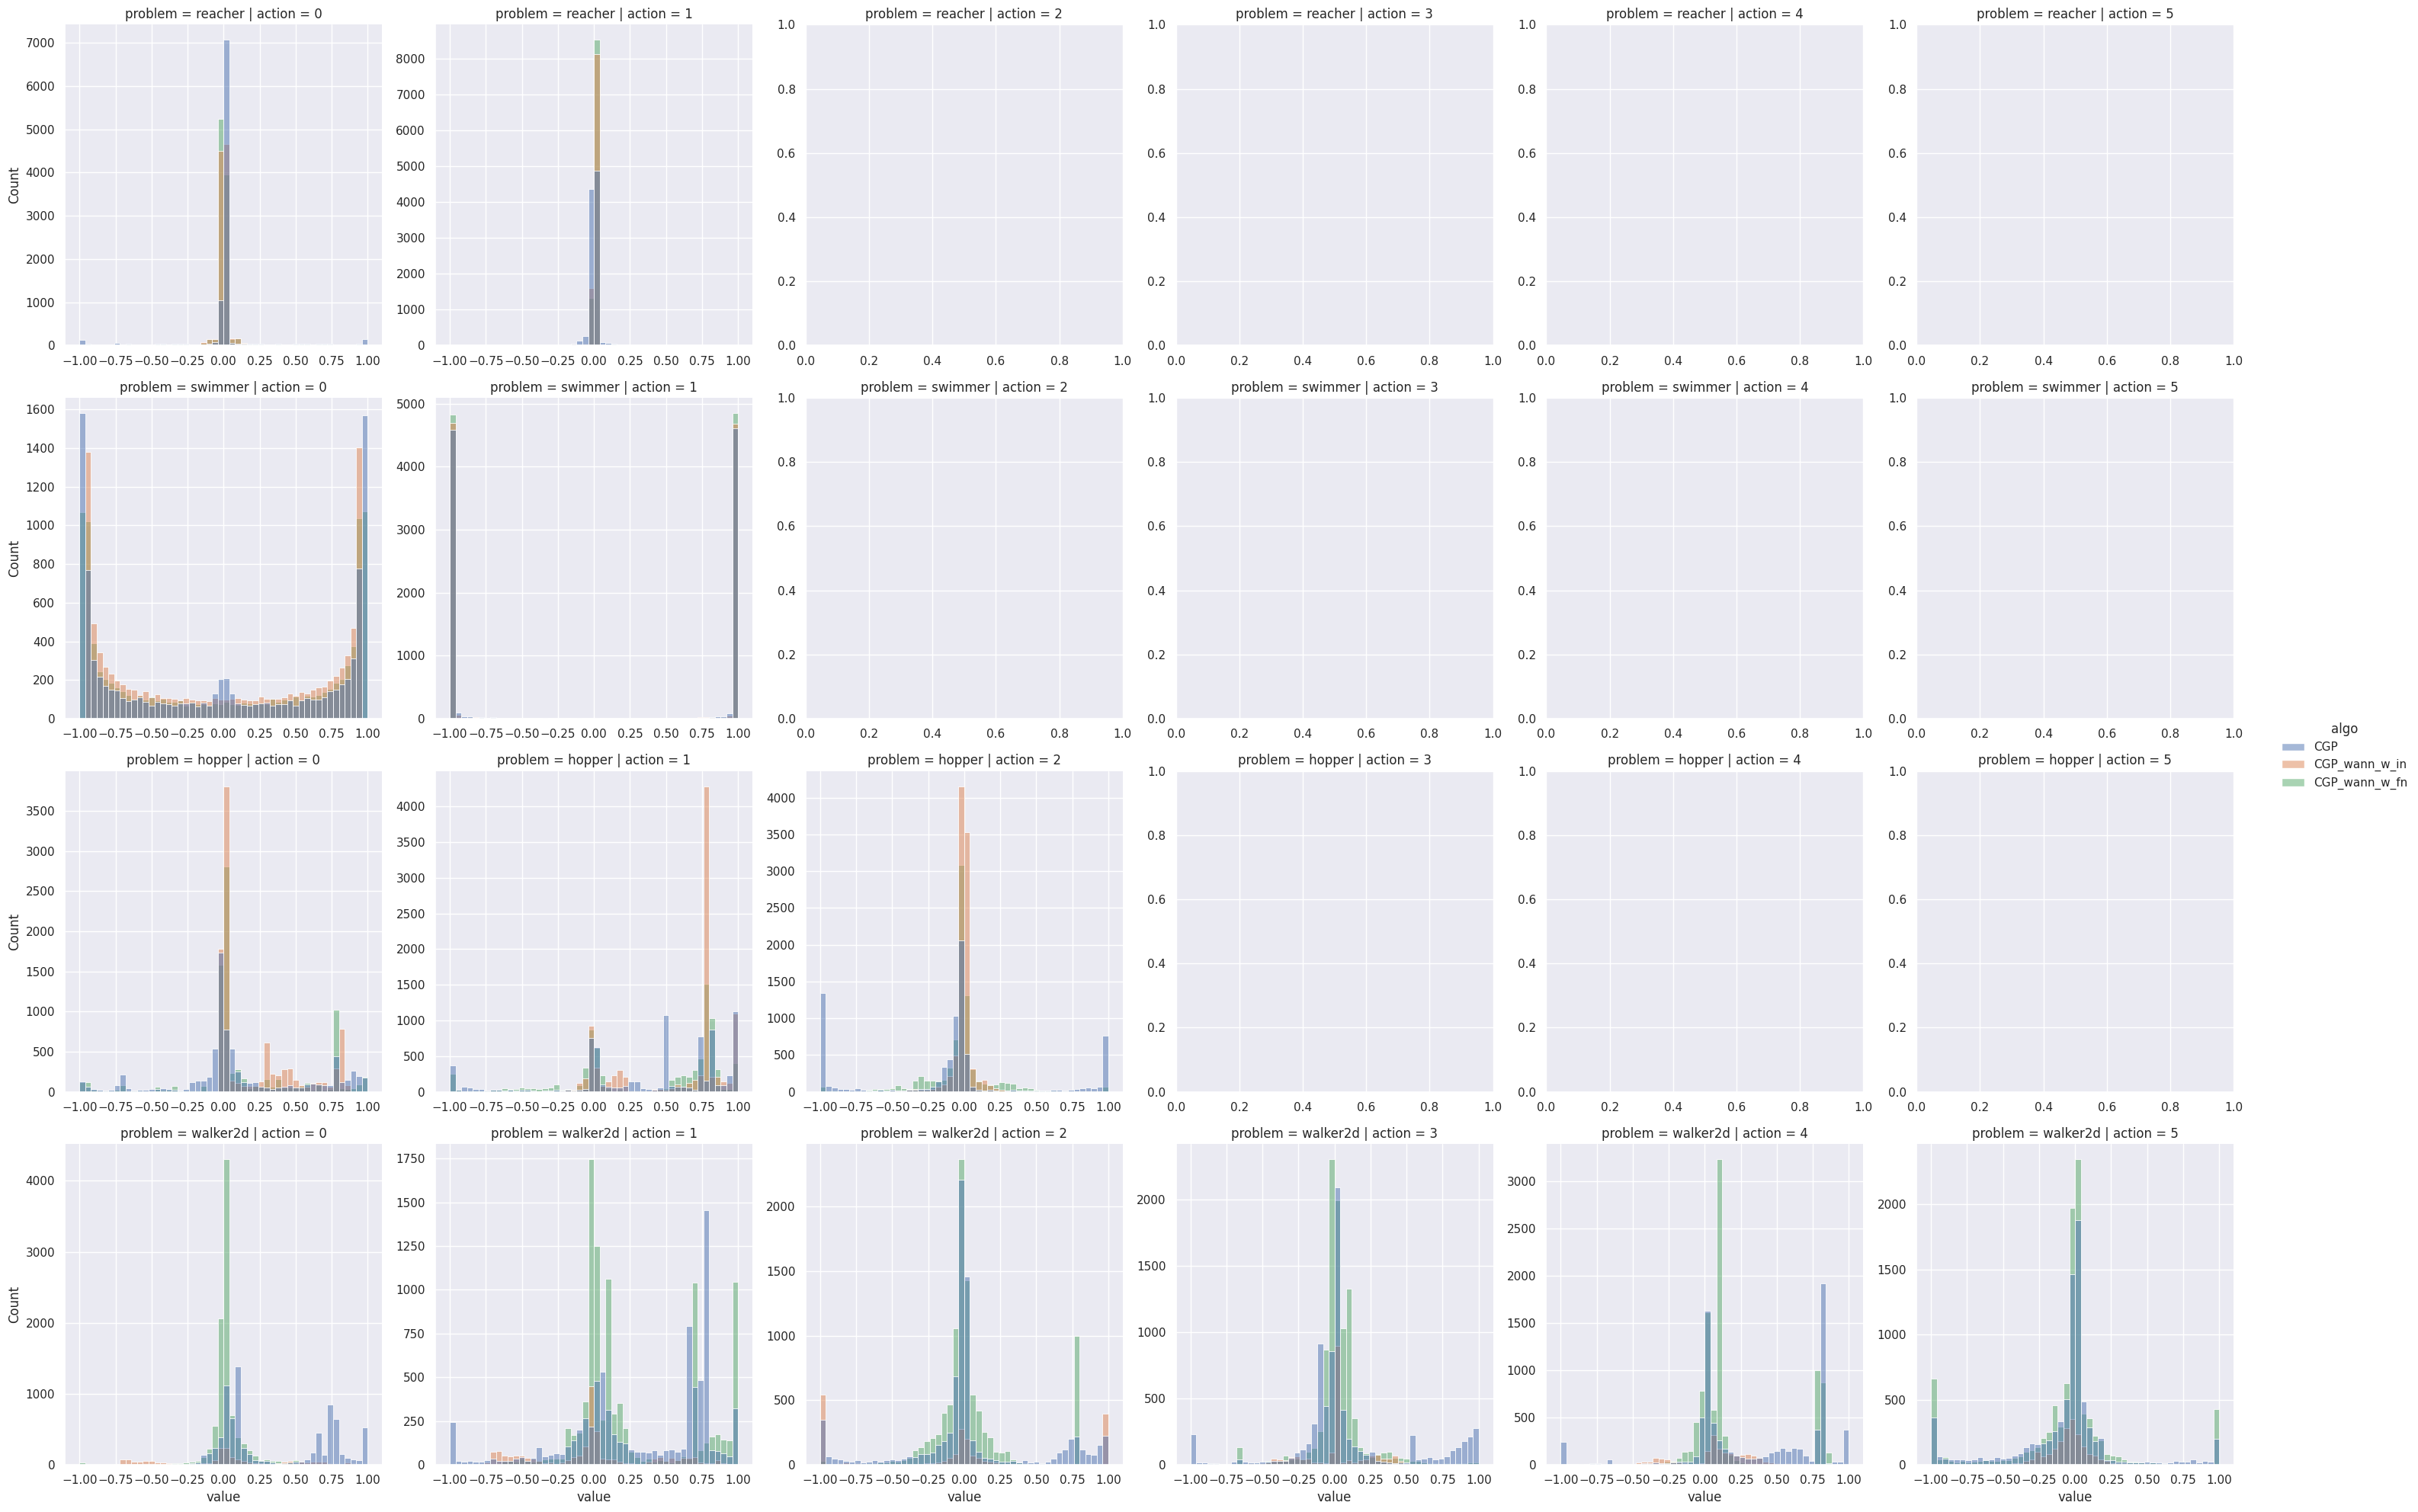

In [12]:
sns.displot(
    data=df,
    x="value",
    col="action",
    row="problem",
    hue="algo",
    bins=50,
    facet_kws={"sharex": False, "sharey": False},
)
plt.show()

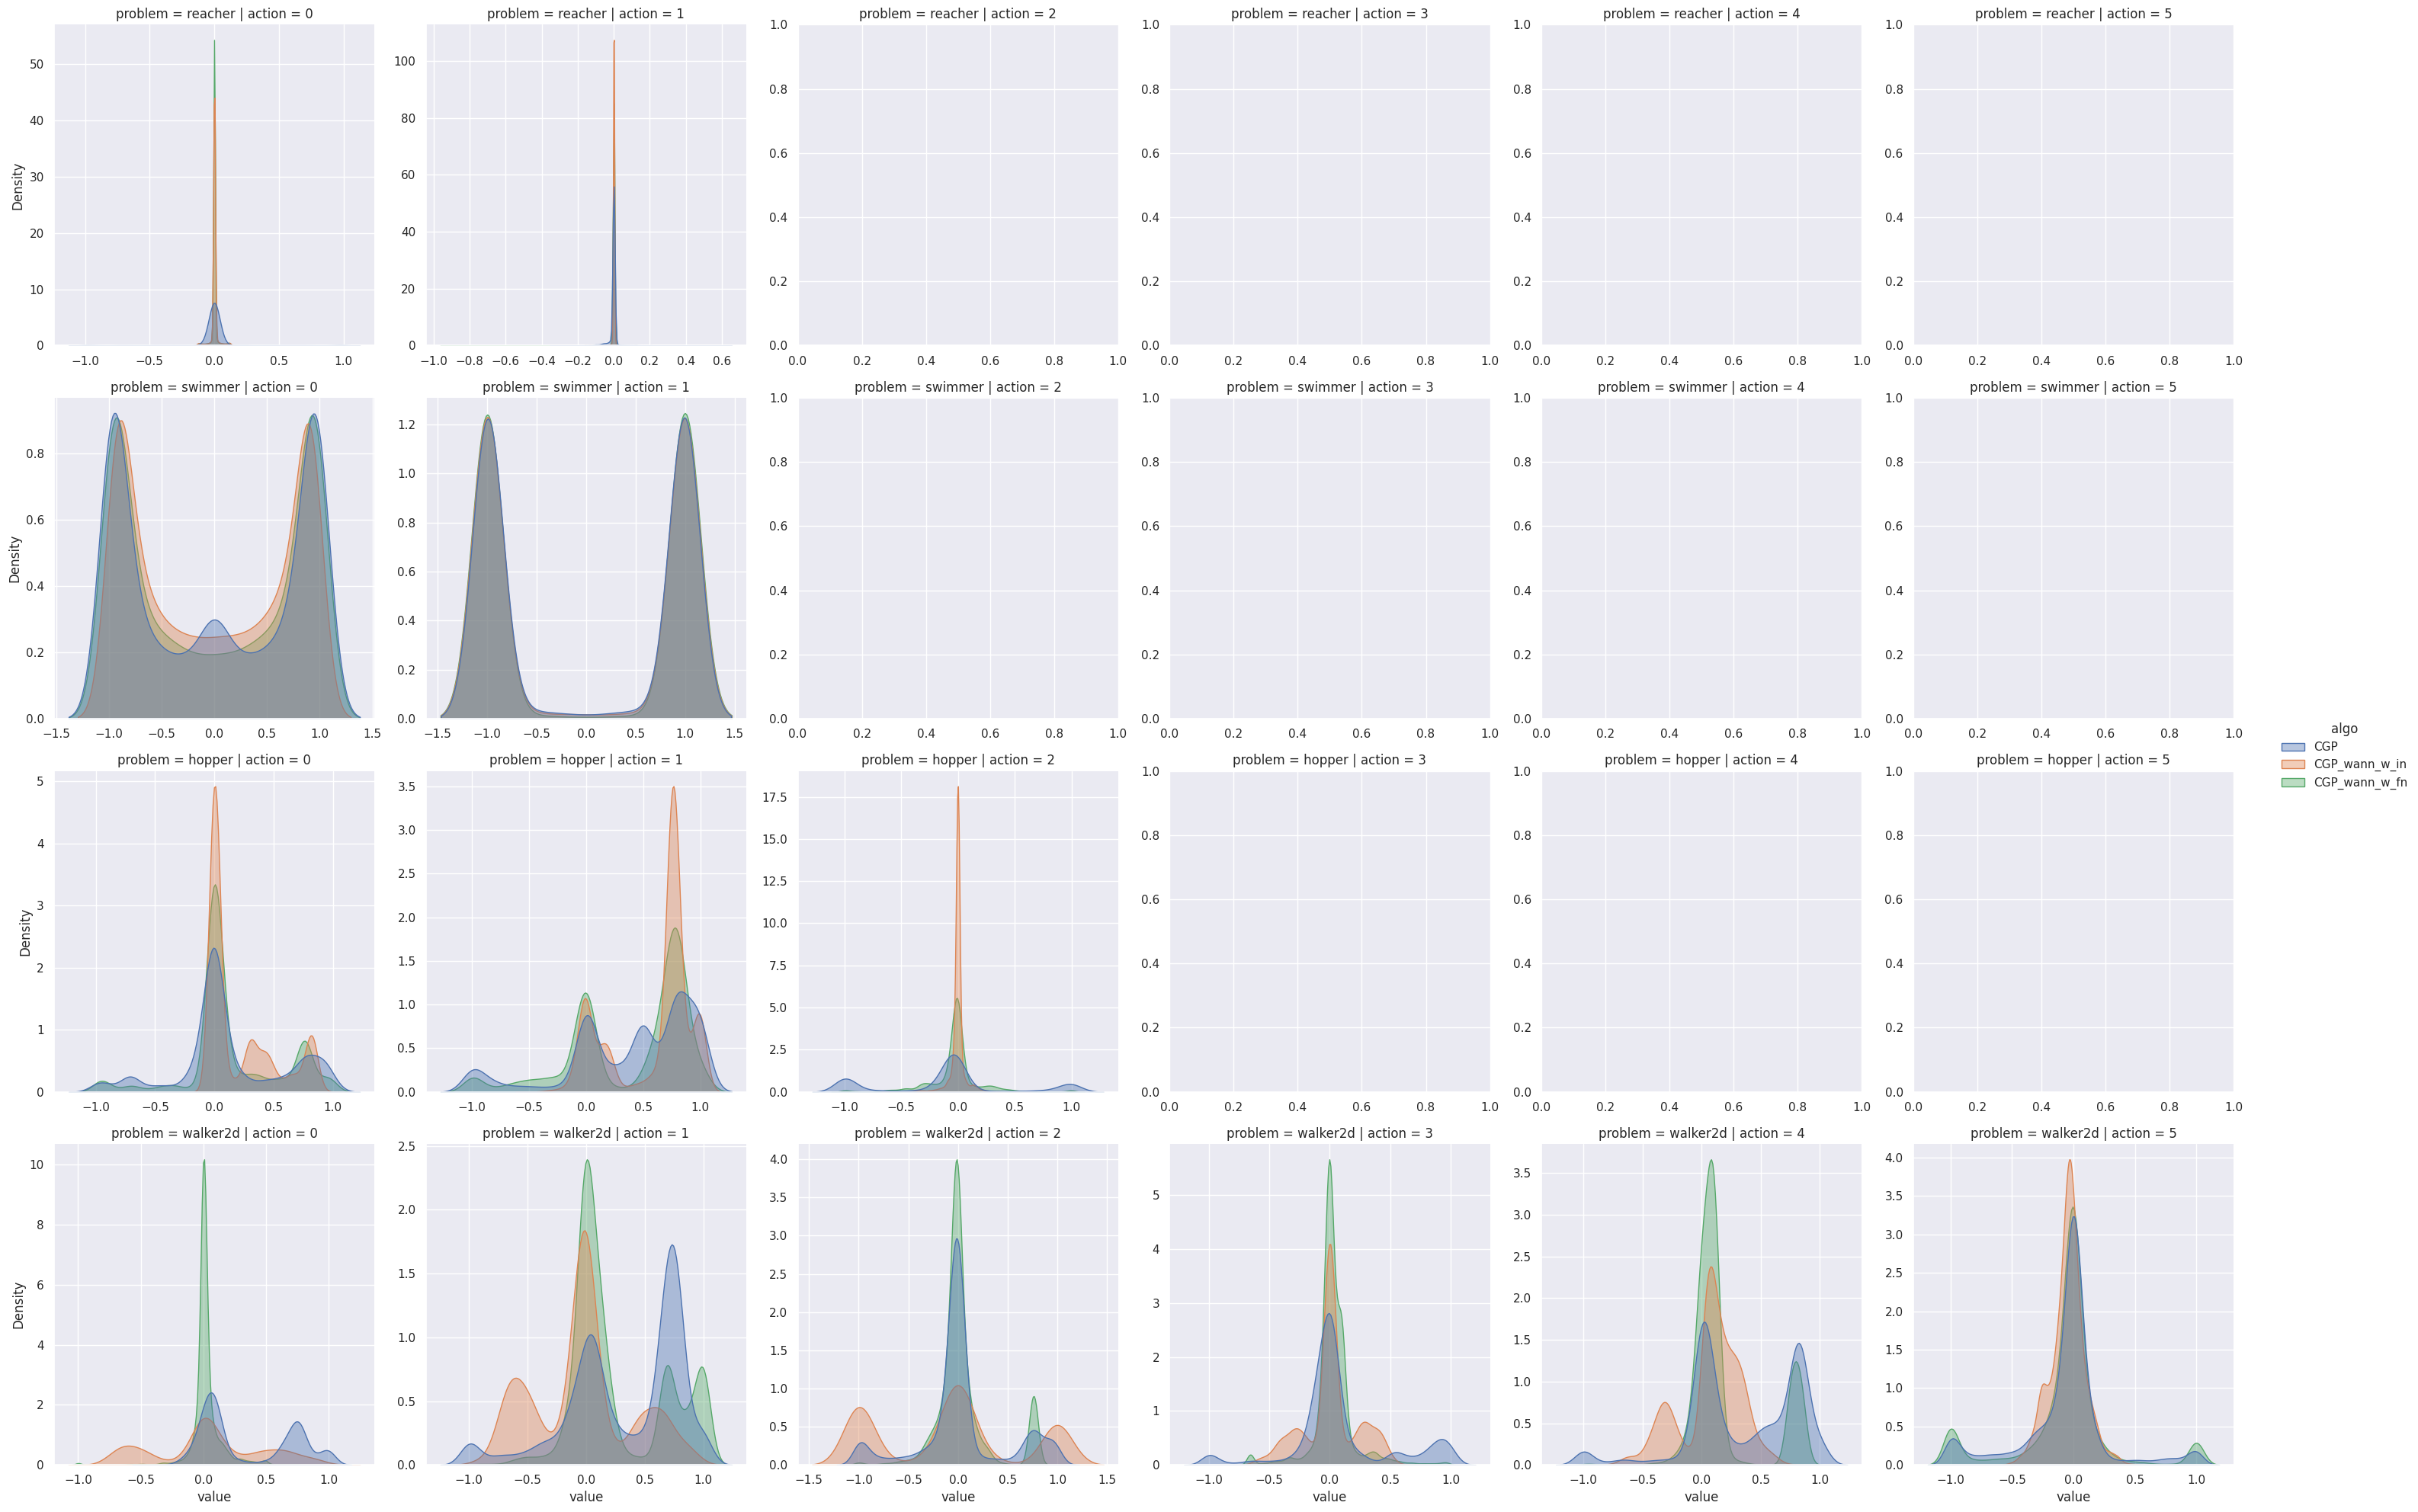

In [13]:
sns.displot(
    data=df,
    x="value",
    col="action",
    row="problem",
    hue="algo",
    kind="kde",
    fill=True,
    common_norm=False,
    alpha=0.4,
    facet_kws={"sharex": False, "sharey": False},
)
plt.show()

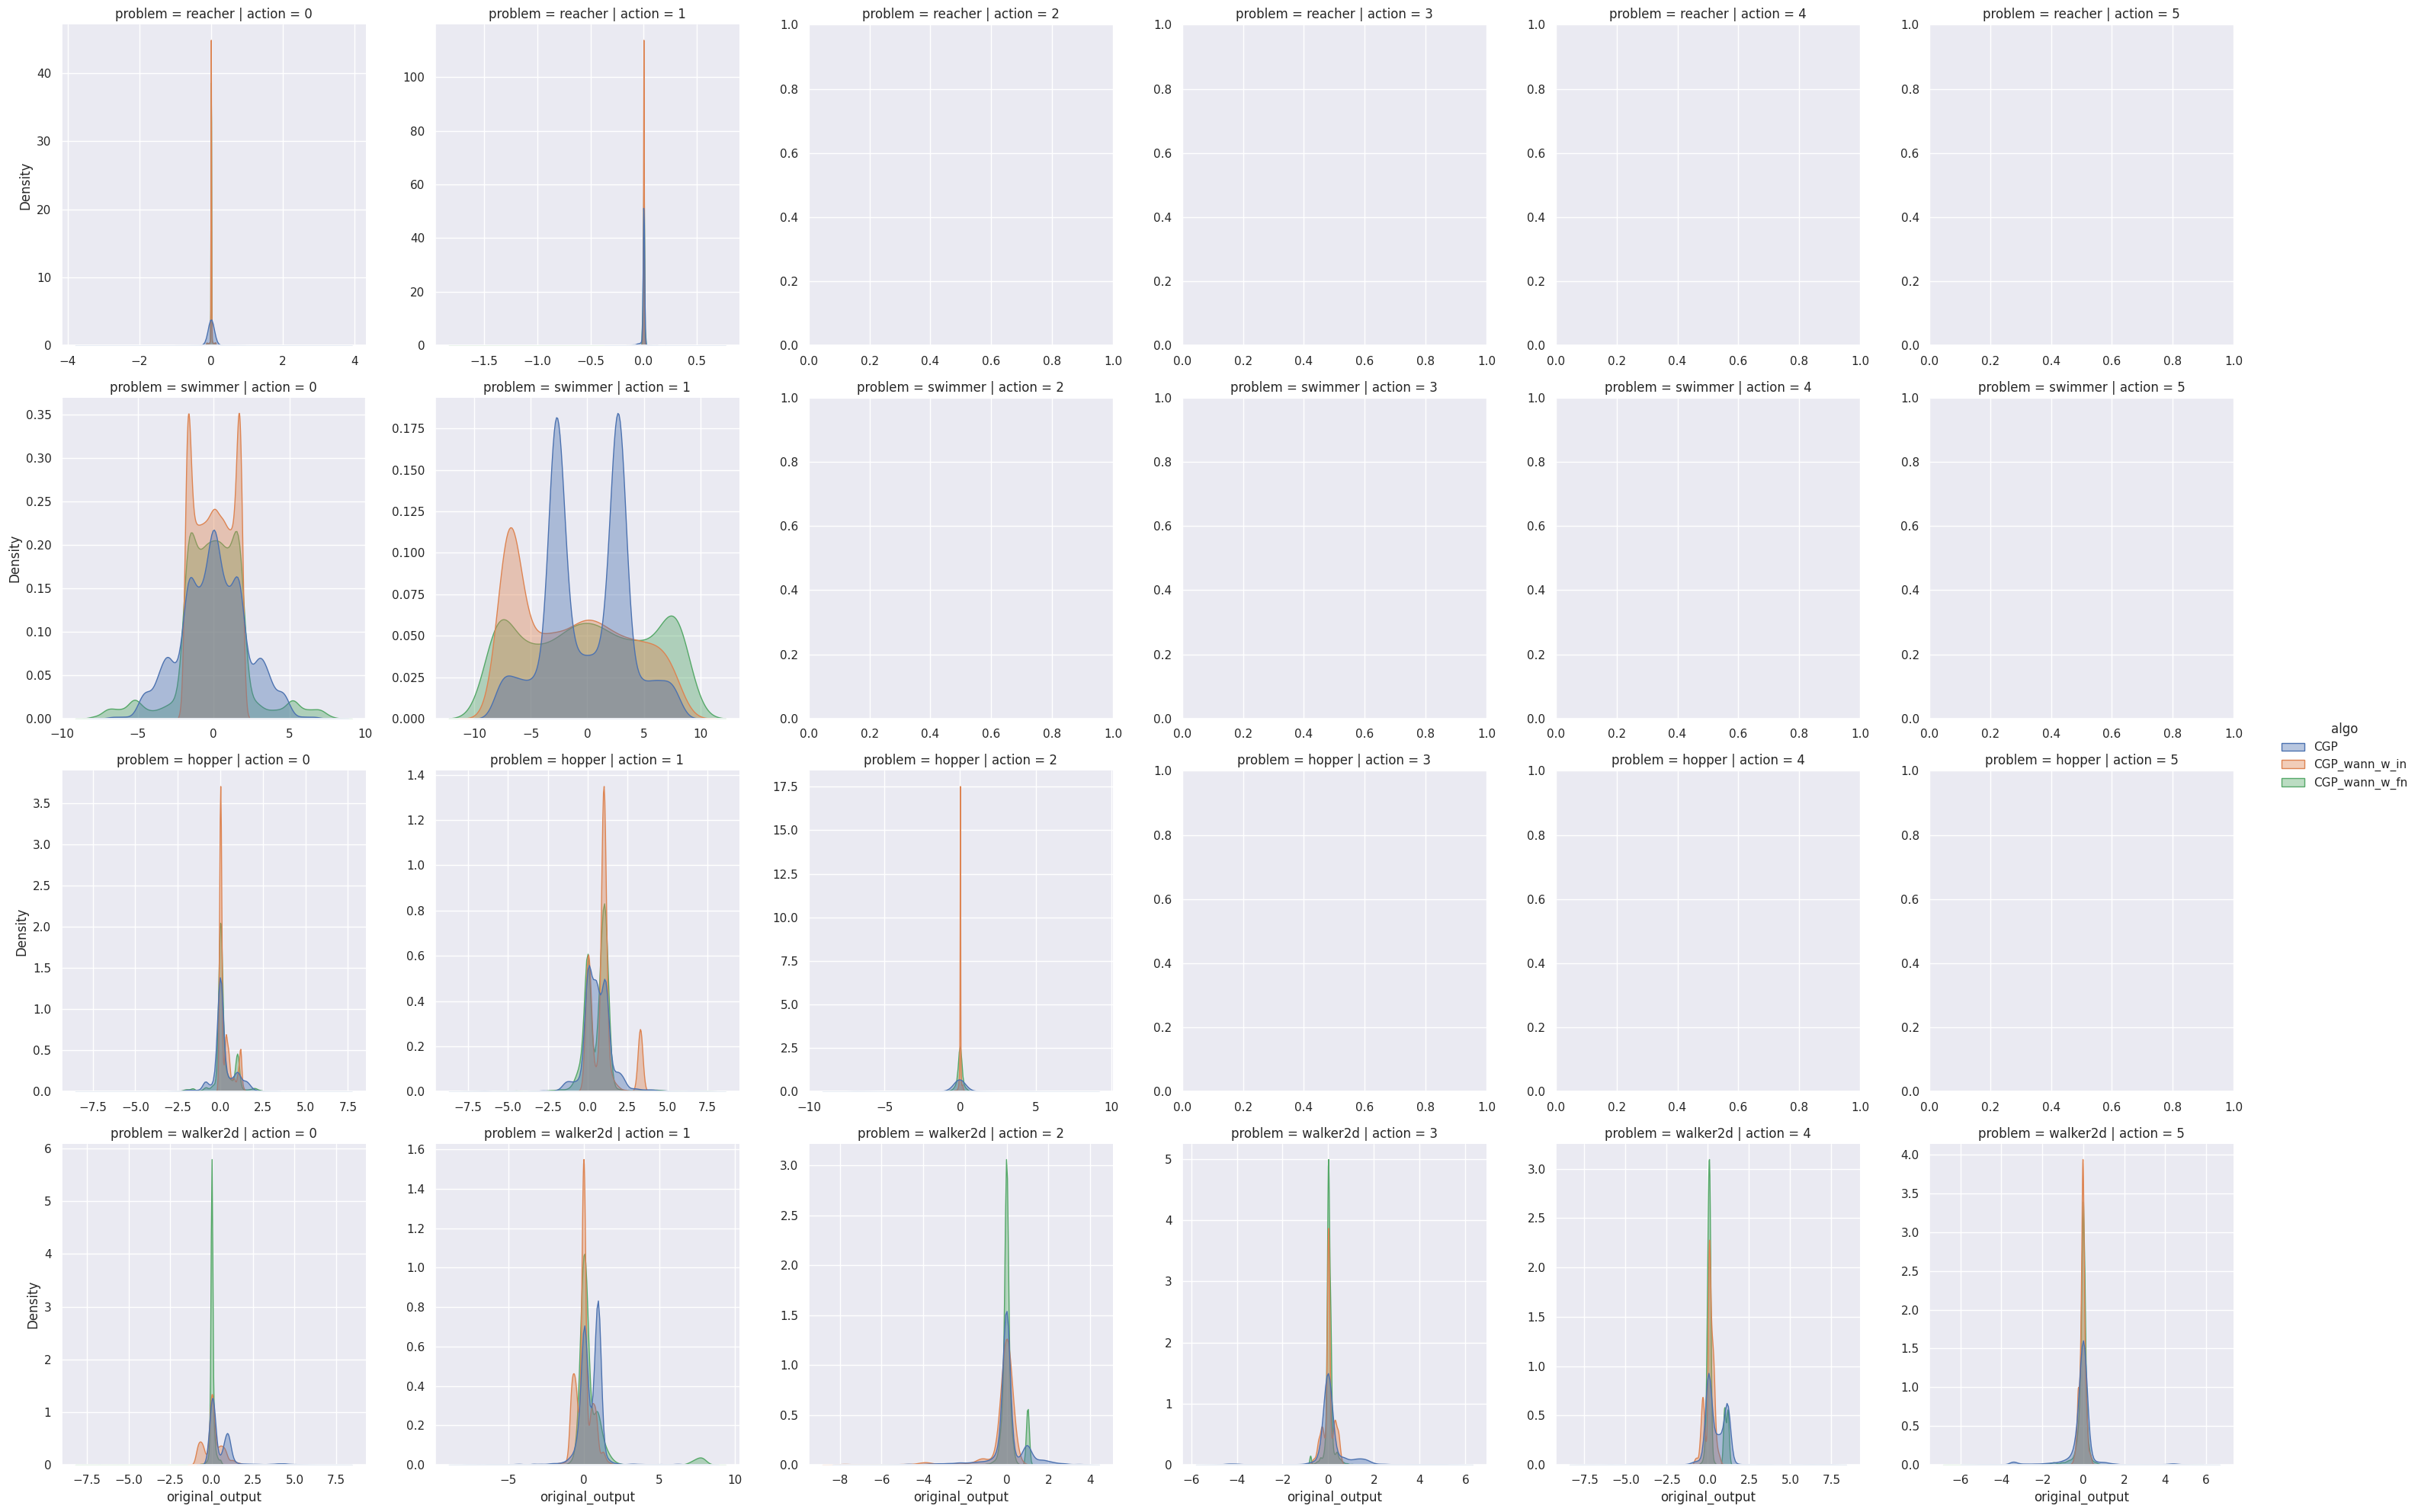

In [14]:
sns.displot(
    data=df,
    x="original_output",
    col="action",
    row="problem",
    hue="algo",
    kind="kde",
    fill=True,
    common_norm=False,
    alpha=0.4,
    facet_kws={"sharex": False, "sharey": False},
)
plt.show()

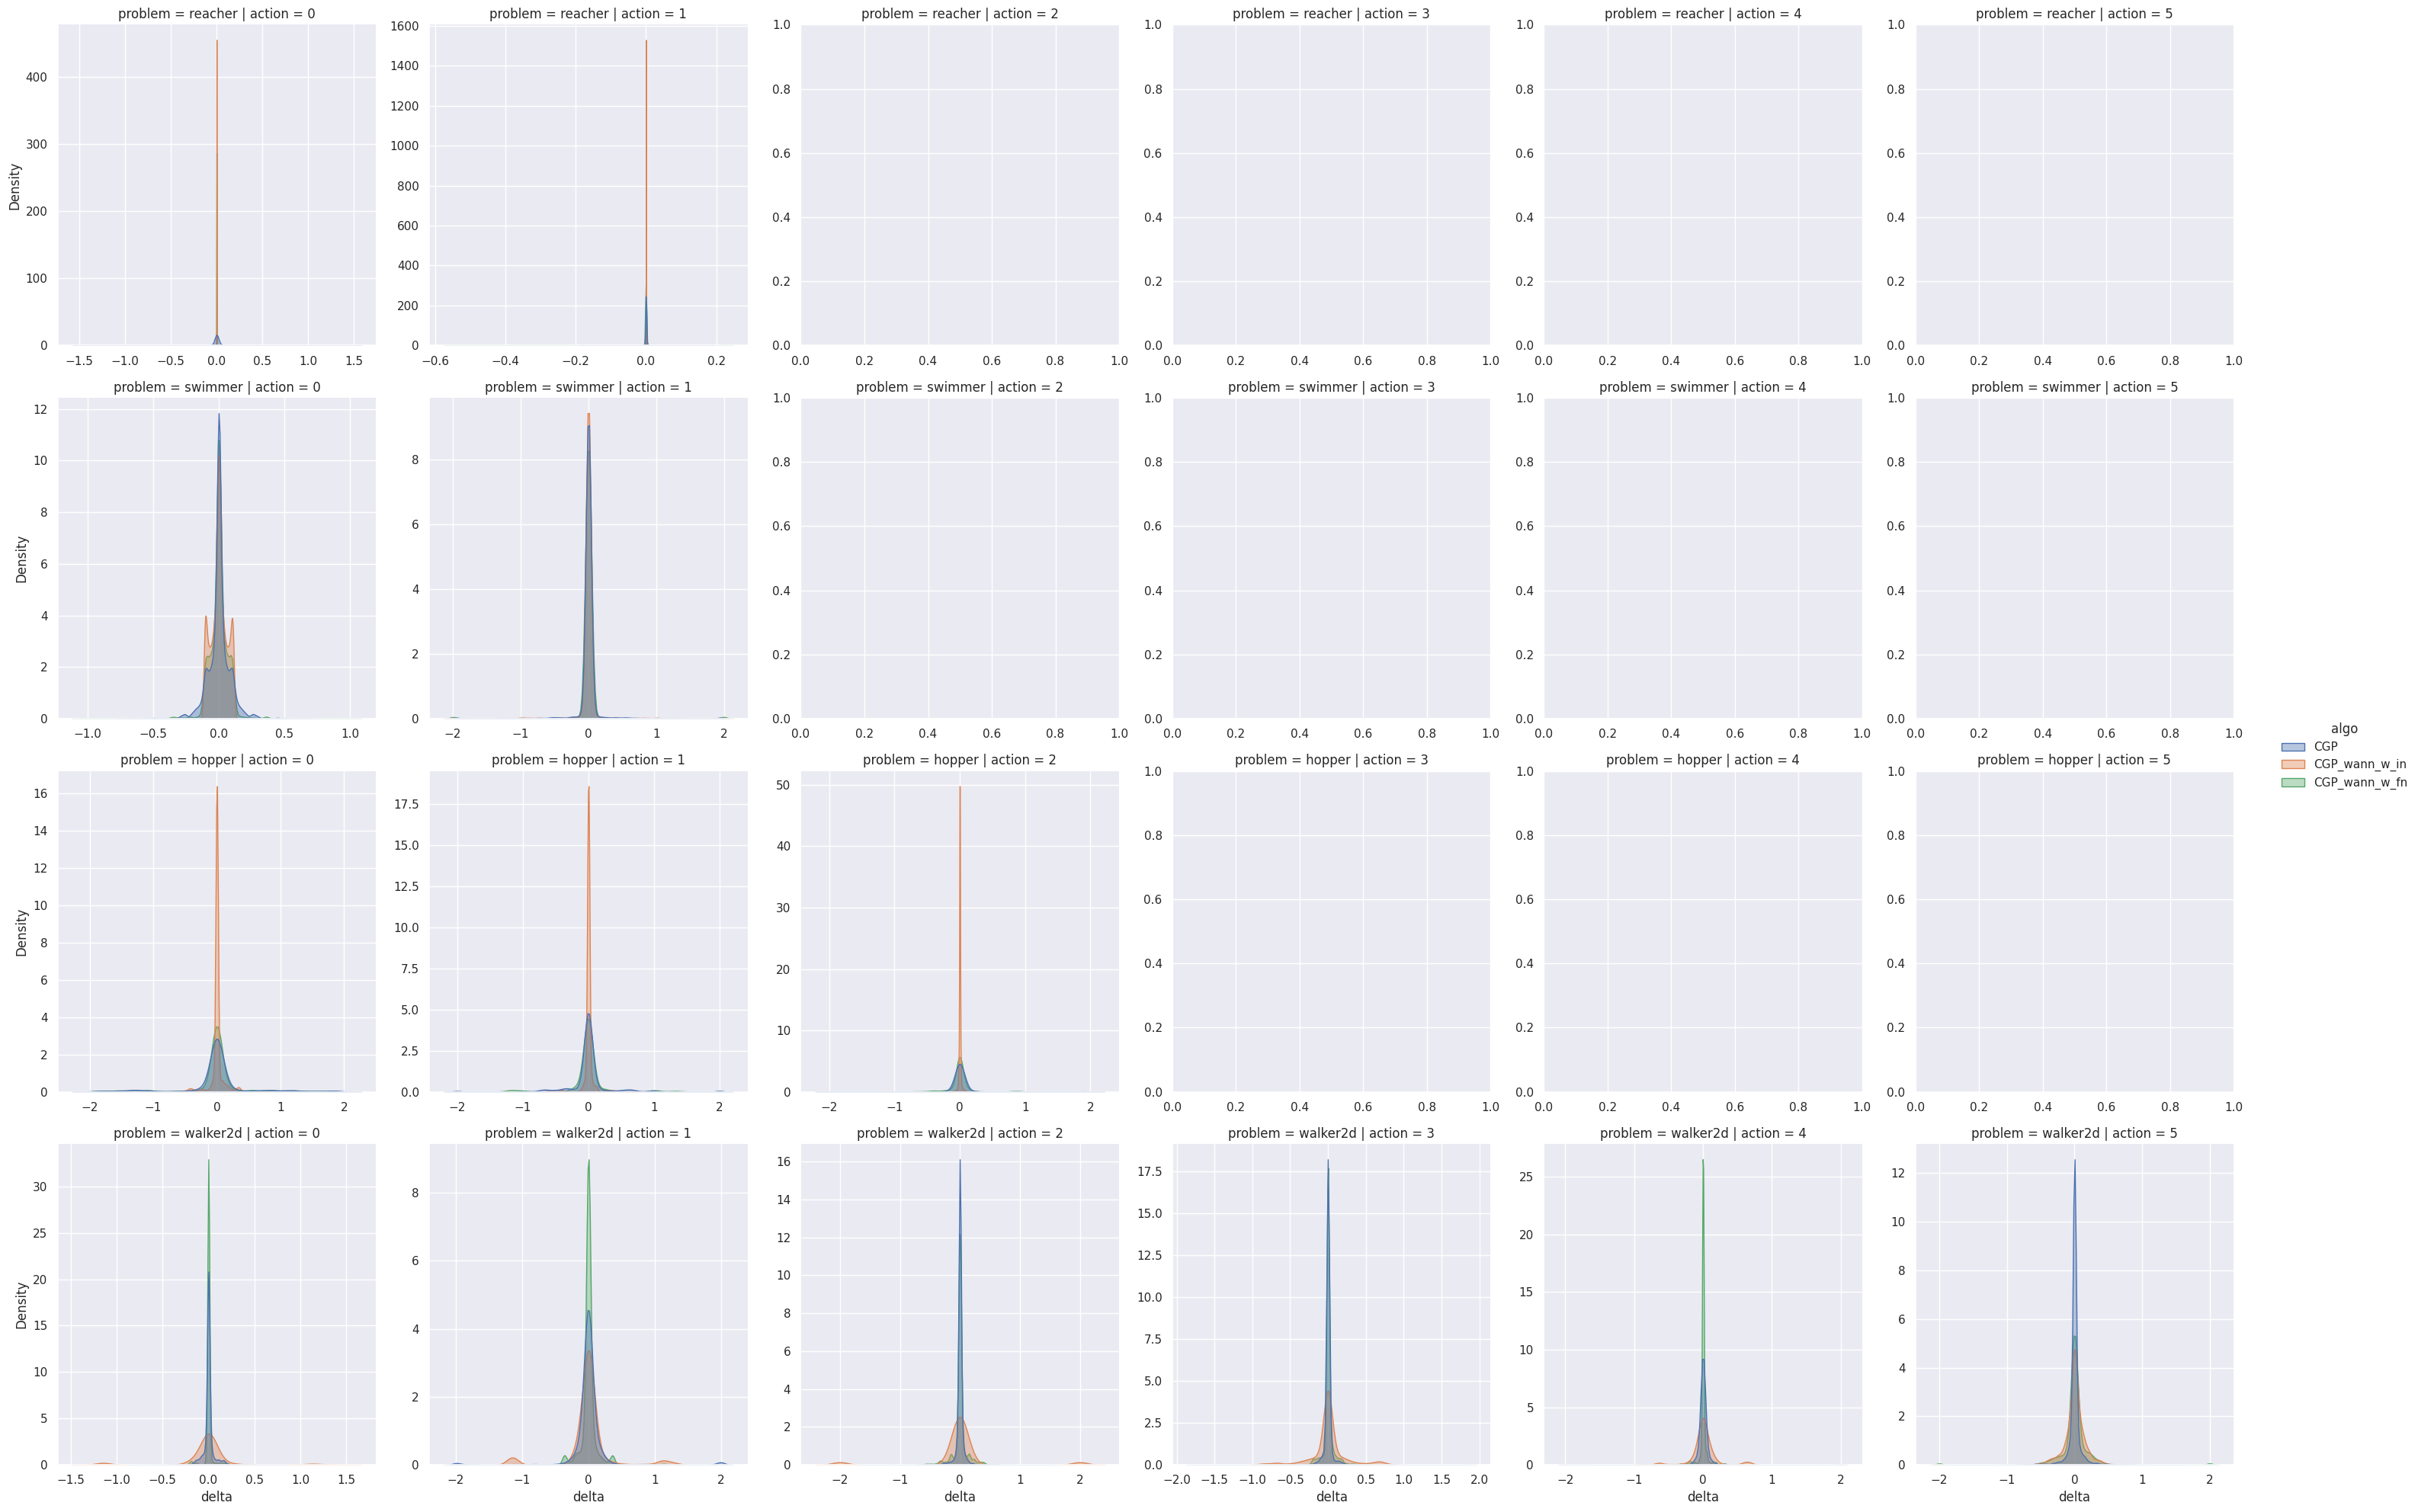

In [15]:
sns.displot(
    data=df,
    x="delta",
    col="action",
    row="problem",
    hue="algo",
    kind="kde",
    fill=True,
    common_norm=False,
    alpha=0.4,
    facet_kws={"sharex": False, "sharey": False},
)
plt.show()